## Text Generation with Character-Level RNNs: LSTM and GRU
## Part 1: Lab Setup
### 1.1 Install Libraries

In [6]:
!pip install tensorflow matplotlib
!pip install numpy
!pip install pandas

### 1.2 Import Required Packages

In [7]:
import numpy as np
import os
os.environ["TF_USE_CUDNN_RNN"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
import time
import matplotlib.pyplot as plt
import pandas as pd

Num GPUs Available: 1


## Part 2: Load and Preprocess Shakespeare Dataset

In [8]:
path_to_file = tf.keras.utils.get_file(
    "shakespeare.txt",
    "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
)

text = open(path_to_file, "rb").read().decode(encoding="utf-8")

print(f"Length of text: {len(text)} characters")
print(text[:500])

Length of text: 1115394 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


### 2.1 Character Vocabulary

In [9]:
vocab = sorted(set(text))

char2idx = {u: i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)

text_as_int = np.array([char2idx[c] for c in text])

print(f"Vocabulary size: {len(vocab)}")
print("Example characters:", vocab[:20])
print("Encoded sample:", text_as_int[:20])

Vocabulary size: 65
Example characters: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G']
Encoded sample: [18 47 56 57 58  1 15 47 58 47 64 43 52 10  0 14 43 44 53 56]


### 2.2 Create Training Sequences

In [10]:
seq_length = 100
examples_per_epoch = len(text) // (seq_length + 1)

char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

for input_example, target_example in dataset.take(1):
    print("Input length:", len(input_example))
    print("Target length:", len(target_example))
    print("Input sample:")
    print("".join(idx2char[input_example.numpy()[:80]]))
    print("\nTarget sample:")
    print("".join(idx2char[target_example.numpy()[:80]]))

Input length: 100
Target length: 100
Input sample:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

Target sample:
irst Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.



I0000 00:00:1787022271.430171    3814 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1787022271.430261    3814 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1787022271.430295    3814 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1787022271.586829    3814 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1787022271.586941    3814 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

## Part 3: Prepare Dataset for Training

In [11]:
BATCH_SIZE = 64
BUFFER_SIZE = 10000

data = (
    dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

for input_batch, target_batch in data.take(1):
    print("Input batch shape:", input_batch.shape)
    print("Target batch shape:", target_batch.shape)

Input batch shape: (64, 100)
Target batch shape: (64, 100)


## Part 4: Build RNN Model
### 4.1 LSTM Model Definition

In [12]:
def build_model(vocab_size, embedding_dim, rnn_units, cell_type="lstm", input_length=None):
    model = tf.keras.Sequential(name=f"character_level_{cell_type}")

    model.add(tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=input_length))

    if cell_type == "lstm":
        model.add(tf.keras.layers.LSTM(rnn_units, return_sequences=True, unroll=True))
    elif cell_type == "gru":
        model.add(tf.keras.layers.GRU(rnn_units, return_sequences=True, unroll=True))
    else:
        raise ValueError("cell_type must be either 'lstm' or 'gru'.")

    model.add(tf.keras.layers.Dense(vocab_size))

    return model

vocab_size = len(vocab)
embedding_dim = 256
rnn_units = 1024

model_lstm = build_model(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    rnn_units=rnn_units,
    cell_type="lstm",
    input_length=seq_length
)

model_lstm.summary()

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Model: "character_level_lstm"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 256)          16640     
                                                                 
 lstm (LSTM)                 (None, 100, 1024)         5246976   
                                                                 
 dense (Dense)               (None, 100, 65)           66625     
                                                                 
Total params: 5330241 (20.33 MB)
Trainable params: 5330241 (20.33 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### 4.2 Compile the Model

In [13]:
def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(
        labels,
        logits,
        from_logits=True
    )

model_lstm.compile(
    optimizer="adam",
    loss=loss
)

## Part 5: Train the LSTM Model

In [14]:

EPOCHS = 10

start_time = time.time()

history_lstm = model_lstm.fit(
    data,
    epochs=EPOCHS
)

training_time_lstm = time.time() - start_time

print(f"LSTM training time: {training_time_lstm:.2f} seconds")

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1787022289.097519    4011 service.cc:146] XLA service 0x7e17b576a140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787022289.097603    4011 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1787022289.185782    4011 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized

  4/172 [..............................] - ETA: 14s - loss: 4.4940  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


  8/172 [>.............................] - ETA: 13s - loss: 4.1686

...

 27/172 [===>..........................] - ETA: 11s - loss: 3.6353

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


172/172 [==============================] - 21s 79ms/step - loss: 2.8412
Epoch 2/10
172/172 [==============================] - 14s 80ms/step - loss: 2.1066
Epoch 3/10
172/172 [==============================] - 14s 80ms/step - loss: 1.8340
Epoch 4/10
172/172 [==============================] - 14s 79ms/step - loss: 1.6599
Epoch 5/10
172/172 [==============================] - 14s 80ms/step - loss: 1.5461
Epoch 6/10
172/172 [==============================] - 14s 75ms/step - loss: 1.4678
Epoch 7/10
172/172 [==============================] - 13s 74ms/step - loss: 1.4098
Epoch 8/10
172/172 [==============================] - 15s 80ms/step - loss: 1.3645
Epoch 9/10
 16/172 [=>............................] - ETA: 12s - loss: 1.3212 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


172/172 [==============================] - 13s 73ms/step - loss: 1.3279
Epoch 10/10
172/172 [==============================] - 15s 80ms/step - loss: 1.2949
LSTM training time: 147.68 seconds


### Plot Training Loss

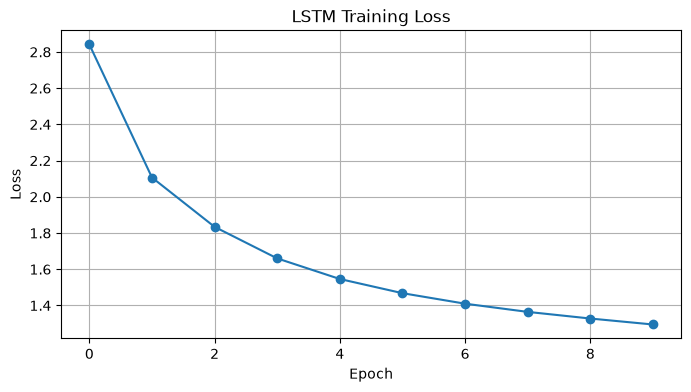

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(history_lstm.history["loss"], marker="o")
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## Part 6: Text Generation Function
### 6.1 One-Step Generation

In [16]:
def generate_text(model, start_string, temperature=1.0, num_generate=1000):
    input_eval = [char2idx[s] for s in start_string if s in char2idx]
    input_eval = tf.expand_dims(input_eval, 0)

    # Pad or truncate to seq_length for unrolled model
    current_len = input_eval.shape[1]
    if current_len < seq_length:
        padding = tf.zeros((1, seq_length - current_len), dtype=tf.int32)
        input_eval = tf.concat([padding, input_eval], axis=1)
    elif current_len > seq_length:
        input_eval = input_eval[:, -seq_length:]

    text_generated = []

    for i in range(num_generate):
        predictions = model(input_eval)

        # Use only the last time step.
        predictions = predictions[:, -1, :] / temperature

        predicted_id = tf.random.categorical(
            predictions,
            num_samples=1
        )[-1, 0].numpy()

        # Sliding window: shift left and append predicted char
        input_eval = tf.concat(
            [input_eval[:, 1:], tf.expand_dims([predicted_id], 0)], axis=1
        )

        text_generated.append(idx2char[predicted_id])

    return start_string + "".join(text_generated)

### 6.2 Generate Sample Text
### !! Please wait

In [17]:
generated_lstm = generate_text(
    model_lstm,
    start_string="To be, or not to be: ",
    temperature=1.0,
    num_generate=1000
)

print(generated_lstm)

To be, or not to be: my lord, In spite and Tribubas in my
With Claudious unlight flies.

Lurenels:
She must I do?

CAMILLO:
I, print you, and is this subject unwill!

ANTONIO:
No, Warwick, lords Lowour.

Marsing Mardle:
I have the other remembranced peace.

LUCENTIO:
Fould year so this madely father.

SICINIUS:
Not of bearest anongue.

AUTOLYCUS:
Thou shalt not only be. I say, I prithee
In thy part between thy true; as break i'en
consul with you; fetch a diffithce lunerious
Thouch frothed in the crownst shorwless garlicome!
To my sweet young, shake shall shrew a slanter;
And dear sound thy head gone bale: dear be
Both of fult as from my botoments to me.

WARWICK:
Who, gentle leys!
This weather, as wherefore desend and buck'd stabling,
Thy vool yes, my mistress newiris age?
IXend by my water'd time, I'll be my goodful only.

ROMEO:
Madam.

LEONTES:
A mother in a substance gone: but friar
Than A word that it wise forgot.

SICINIUS:
I can led it too laugh to make a ole.

WERMILLAND:
Then 

### 6.3 Temperature-Controlled Sampling

In [13]:
for temp in [0.5, 1.0, 1.5]:
    print("\n" + "=" * 80)
    print(f"Temperature: {temp}")
    print("=" * 80)

    print(
        generate_text(
            model_lstm,
            start_string="To be, or not to be: ",
            temperature=temp,
            num_generate=500
        )
    )


Temperature: 0.5
To be, or not to be: I was a soldier to be desires.

POLIXENES:
Though the earth of heart when I see the prince,
But which now lies this change fill to him.

BIONDELLO:
That shall I fear the world shall death.

MENENIUS:
I am not the bride and the king, and grant
That thou art that the king shall say the world.

PETRUCHIO:
I have son as in the charge be think of the state,
The valiant call in this death be a complexion.

ESCALUS:
Madam, sir, then all when the princeling foot,
I am all counterful man, and happy most 

Temperature: 1.0
To be, or not to be: I Gaunt men that 'goneth so manstary,
His seasonalunest, of York of Warwick
Till betwralm from wife in the destorable,
Is neck the wap powanders of Jonnarm'?

Provost:
What's the vanton-should
soul, the dage from hope, yet I subslied, can
Duke in the carron perent neillst, sign,
That tells not unto mere known beggars'd, carling
Fortune form for the meritent.
To mont finding of him! then reploud stain
the prisoners: bu

## Part 7: GRU vs LSTM Comparison
### Repeat model construction, training, and generation using a GRU cell.

In [18]:
model_gru = build_model(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    rnn_units=rnn_units,
    cell_type="gru",
    input_length=seq_length
)

model_gru.compile(
    optimizer="adam",
    loss=loss
)

model_gru.summary()

start_time = time.time()

history_gru = model_gru.fit(
    data,
    epochs=EPOCHS
)

training_time_gru = time.time() - start_time

print(f"GRU training time: {training_time_gru:.2f} seconds")

Model: "character_level_gru"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 100, 256)          16640     
                                                                 
 gru (GRU)                   (None, 100, 1024)         3938304   
                                                                 
 dense_1 (Dense)             (None, 100, 65)           66625     
                                                                 
Total params: 4021569 (15.34 MB)
Trainable params: 4021569 (15.34 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


  1/172 [..............................] - ETA: 24:08 - loss: 4.1741

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


  4/172 [..............................] - ETA: 19s - loss: 4.0819  

...

 94/172 [===============>..............] - ETA: 6s - loss: 3.0912

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


172/172 [==============================] - 22s 78ms/step - loss: 2.7289
Epoch 2/10
172/172 [==============================] - 14s 75ms/step - loss: 2.0000
Epoch 3/10
172/172 [==============================] - 14s 80ms/step - loss: 1.7248
Epoch 4/10
172/172 [==============================] - 14s 78ms/step - loss: 1.5644
Epoch 5/10
172/172 [==============================] - 15s 80ms/step - loss: 1.4638
Epoch 6/10
172/172 [==============================] - 14s 76ms/step - loss: 1.3958
Epoch 7/10
172/172 [==============================] - 14s 79ms/step - loss: 1.3418
Epoch 8/10
172/172 [==============================] - 14s 80ms/step - loss: 1.2974
Epoch 9/10
135/172 [======================>.......] - ETA: 2s - loss: 1.2557  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


172/172 [==============================] - 13s 74ms/step - loss: 1.2572
Epoch 10/10
172/172 [==============================] - 14s 75ms/step - loss: 1.2190
GRU training time: 147.95 seconds


### Compare Training Loss and Generated Text

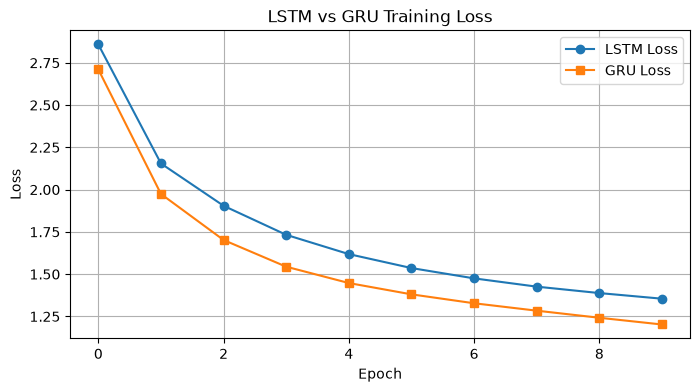

LSTM generated text:
To be, or not to be: a fortenso--
But say, who wayst more how of yourself, you meet:
Ratersy truth, repeanded to his tongue in the old
From; so much'd kinded gromio's beasts, in doubt
Till st bloody. O Presserph call mate!

GONZALO:
Do you, He's not be long Pewil with to lie;
But doth gently nor courtesters distersed;
To-morrow me, of any great tears. From whouch
Without wingdess firest dim be lungul,
have deniedly to cry Boningable,
Eithers and here in't whom to mine hands weep,
And satisies that man dreams man to 

GRU generated text:
To be, or not to be: king of mercy love,
Thou and the favour wault or feets,
May--the heaven of your myself,
Or else you layed, now to your,
Have I not dead me with free,--look you be false,
And whither yet consul.

Coriold:
Who will you meets? dispatch! Are you, sir, Prince Edward Shall not med; go fire,
That let me dead let me firer
renown than he has pitted and strife, such as
and in their own powers'? Very met, with wounds
O'elo

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(history_lstm.history["loss"], label="LSTM Loss", marker="o")
plt.plot(history_gru.history["loss"], label="GRU Loss", marker="s")
plt.title("LSTM vs GRU Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

print("LSTM generated text:")
print(generate_text(model_lstm, start_string="To be, or not to be: ", num_generate=500))

print("\nGRU generated text:")
print(generate_text(model_gru, start_string="To be, or not to be: ", num_generate=500))

## Part 8: Summarize the Comparison
### Use the following table to compare final loss and training time.

In [19]:
comparison = {
    "Model": ["LSTM", "GRU"],
    "Final Loss": [
        history_lstm.history["loss"][-1],
        history_gru.history["loss"][-1]
    ],
    "Training Time (seconds)": [
        training_time_lstm,
        training_time_gru
    ]
}

comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,Final Loss,Training Time (seconds)
0,LSTM,1.294914,147.682089
1,GRU,1.218960,147.951288


## Part 9: Optional Experiments

In [20]:
# Optional experiment ideas:
# 1. Add Dropout after the LSTM or GRU layer.
# 2. Add LayerNormalization.
# 3. Try a Bidirectional RNN.
# 4. Change sequence length from 100 to 50 or 150.
# 5. Change batch size from 64 to 32 or 128.
# 6. Replace Shakespeare with a custom corpus.

def build_model_with_dropout(vocab_size, embedding_dim, rnn_units, cell_type="lstm", input_length=None):
    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=input_length))

    if cell_type == "lstm":
        model.add(tf.keras.layers.LSTM(rnn_units, return_sequences=True, unroll=True))
    else:
        model.add(tf.keras.layers.GRU(rnn_units, return_sequences=True, unroll=True))

    model.add(tf.keras.layers.Dropout(0.3))
    model.add(tf.keras.layers.LayerNormalization())
    model.add(tf.keras.layers.Dense(vocab_size))

    return model

## Part 10: Save the Models

In [21]:
model_lstm.save("lecture6_lab3_lstm_character_model.keras")
model_gru.save("lecture6_lab3_gru_character_model.keras")

print("Saved LSTM and GRU models.")

Saved LSTM and GRU models.
